In [36]:
from functools import partial
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
import torchvision
import torchvision.transforms as transforms
!pip install "ray[tune]"
!pip install ray
!pip install torchmetrics
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import torchvision
from torch.optim.lr_scheduler import StepLR
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
from google.colab import drive
import glob
from pathlib import Path

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [37]:
# run this to see all the outputs below each cell, not only the last instruction 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [38]:
# mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# Load labels into a pandas DataFrame
labels_df = pd.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')

# Path to the folder containing the images
images_dir = '/content/drive/MyDrive/data/ByteToImage/ByteToImage'

# Get list of image paths and labels
# X = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.png')]
X = glob.glob('/content/drive/MyDrive/data/ByteToImage/ByteToImage/*.png')

In [40]:
y = []
import pandas
df = pandas.read_csv('/content/drive/MyDrive/data/ByteToImage/trainLabels.csv')
for img in X :
    id = df[df['Id'] == str(Path(img).stem.__str__())]['Class'].iloc[0]
    y.append(id)

In [41]:
# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=40)

In [42]:
# Define a custom function to load and transform data
def load_and_transform_data(X, y, transform):
    data = []
    for i in range(len(X)):
        img_path = X[i]
        img = Image.open(img_path).convert('RGB')
        if transform is not None:
            img = transform(img)
        label = y[i]-1 # labels are in [1,9], should be in [0,8]
        data.append((img, label))
    return data

In [43]:
# Load images and apply transformations # also you can use transforms.Resize((64, 64))
data_transforms = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=(0.5, ), std=(0.5, ))])

train_data = load_and_transform_data(X_train, y_train, transform=data_transforms)
val_data = load_and_transform_data(X_val, y_val, transform=data_transforms)
test_data = load_and_transform_data(X_test, y_test, transform=data_transforms)

batch_size=128

trainloader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [44]:
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [45]:
class Net(nn.Module):
    def __init__(self, num_classes=9, lr=0.001, reg=0.001, device='cpu'):
        super(Net, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        self.fc1 = nn.Linear(256 * 8 * 8 , 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, num_classes)

        # Hyperparameters
        self.lr = lr
        self.reg = reg
        self.num_classes = num_classes
        self.device = device

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool4(F.relu(self.conv4(x)))
        x = x.view(-1, 256 * 8 * 8 )
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x
    def configure_optimizers(self):
        optimizer = optim.SGD(self.parameters(), lr=self.lr, weight_decay=self.reg)
        return optimizer

In [46]:
def train_cifar(config, checkpoint_dir=None):
    net = Net(lr=config["lr"], reg=config["reg"])

    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda:0"
        if torch.cuda.device_count() > 1:
            net = nn.DataParallel(net)
    net.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=config["lr"], weight_decay=config["reg"] )

    if checkpoint_dir:
        model_state, optimizer_state = torch.load(
            os.path.join(checkpoint_dir, "checkpoint"))
        net.load_state_dict(model_state)
        optimizer.load_state_dict(optimizer_state)

    for epoch in range(10):  # loop over the dataset multiple times
        running_loss = 0.0
        epoch_steps = 0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            epoch_steps += 1
            if i % 2000 == 1999:  # print every 2000 mini-batches
                print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1,
                                                running_loss / epoch_steps))
                running_loss = 0.0

        # Validation loss
        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(valloader, 0):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                loss = criterion(outputs, labels)
                val_loss += loss.cpu().numpy()
                val_steps += 1

        with tune.checkpoint_dir(epoch) as checkpoint_dir:
            path = os.path.join(checkpoint_dir, "checkpoint")
            torch.save((net.state_dict(), optimizer.state_dict()), path)

        tune.report(loss=(val_loss / val_steps), accuracy=correct / total)
    print("Finished Training")

In [47]:
def test_accuracy(net, device="cpu"):

    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [56]:
def main(num_samples=10, max_num_epochs=100, gpus_per_trial=1):
    config = {
        "lr": tune.loguniform(5e-2, 2e-1),
        "reg": tune.loguniform(1e-3, 5e-3),
    }
    scheduler = ASHAScheduler(
        metric="loss",
        mode="min",
        max_t=max_num_epochs,
        grace_period=1,
        reduction_factor=2)
    reporter = CLIReporter(
        metric_columns=["loss", "accuracy", "training_iteration"])
    result = tune.run(
        partial(train_cifar),
        resources_per_trial={"cpu": 2, "gpu": gpus_per_trial},
        config=config,
        num_samples=num_samples,
        scheduler=scheduler,
        progress_reporter=reporter)

    best_trial = result.get_best_trial("loss", "min", "last")
    print("Best trial config: {}".format(best_trial.config))
    print("Best trial final validation loss: {}".format(
        best_trial.last_result["loss"]))
    print("Best trial final validation accuracy: {}".format(
        best_trial.last_result["accuracy"]))

    best_trained_model = Net( lr = best_trial.config["lr"], reg = best_trial.config["reg"])
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda:0"
        if gpus_per_trial > 1:
            best_trained_model = nn.DataParallel(best_trained_model)
    best_trained_model.to(device)

    best_checkpoint_dir = best_trial.checkpoint.value
    model_state, optimizer_state = torch.load(os.path.join(
        best_checkpoint_dir, "checkpoint"))
    best_trained_model.load_state_dict(model_state)

    test_acc = test_accuracy(best_trained_model, device)
    print("Best trial test set accuracy: {}".format(test_acc))


if __name__ == "__main__":
    # You can change the number of GPUs per trial here:
    main(num_samples=10, max_num_epochs=100)

2023-04-28 14:24:04,781	WARNING worker.py:1986 -- Warning: The actor ImplicitFunc is very large (41 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
2023-04-28 14:24:05,678	WARNING util.py:244 -- The `start_trial` operation took 4.635 s, which may be a performance bottleneck.


== Status ==
Current time: 2023-04-28 14:24:05 (running for 00:00:21.45)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 64.000: None | Iter 32.000: None | Iter 16.000: None | Iter 8.000: None | Iter 4.000: None | Iter 2.000: None | Iter 1.000: None
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs
Result logdir: /root/ray_results/train_cifar_2023-04-28_14-23-44
Number of trials: 10/10 (9 PENDING, 1 RUNNING)
+-------------------------+----------+-------------------+-----------+------------+
| Trial name              | status   | loc               |        lr |        reg |
|-------------------------+----------+-------------------+-----------+------------|
| train_cifar_48023_00000 | RUNNING  | 172.28.0.12:20574 | 0.0519855 | 0.00179718 |
| train_cifar_48023_00001 | PENDING  |                   | 0.0783059 | 0.00227916 |
| train_cifar_48023_00002 | PENDING  |                   | 0.151247  | 0.00319191 |
| train_cifar_48023_00003 | PENDING  |                   | 0.14267   | 0.00192085 |
|

Trial name,accuracy,date,done,hostname,iterations_since_restore,loss,node_ip,pid,should_checkpoint,time_since_restore,time_this_iter_s,time_total_s,timestamp,training_iteration,trial_id
train_cifar_48023_00000,0.430939,2023-04-28_14-24-29,True,cc080765b31a,10,1.95191,172.28.0.12,20574,True,18.6234,1.50227,18.6234,1682691869,10,48023_00000
train_cifar_48023_00001,0.21547,2023-04-28_14-24-43,True,cc080765b31a,1,2.19515,172.28.0.12,20742,True,6.19721,6.19721,6.19721,1682691883,1,48023_00001
train_cifar_48023_00002,0.671271,2023-04-28_14-25-08,True,cc080765b31a,10,1.70816,172.28.0.12,20843,True,18.9473,1.48021,18.9473,1682691908,10,48023_00002
train_cifar_48023_00003,0.679558,2023-04-28_14-25-34,True,cc080765b31a,10,1.67908,172.28.0.12,21005,True,18.3976,1.52574,18.3976,1682691934,10,48023_00003
train_cifar_48023_00004,0.21547,2023-04-28_14-25-48,True,cc080765b31a,1,2.19547,172.28.0.12,21181,True,6.36971,6.36971,6.36971,1682691948,1,48023_00004
train_cifar_48023_00005,0.475138,2023-04-28_14-26-10,True,cc080765b31a,8,1.88932,172.28.0.12,21277,True,15.6228,1.47659,15.6228,1682691970,8,48023_00005
train_cifar_48023_00006,0.263352,2023-04-28_14-26-24,True,cc080765b31a,1,2.1941,172.28.0.12,21423,True,5.49107,5.49107,5.49107,1682691984,1,48023_00006
train_cifar_48023_00007,0.263352,2023-04-28_14-26-47,True,cc080765b31a,8,2.10447,172.28.0.12,21520,True,16.649,1.47195,16.649,1682692007,8,48023_00007
train_cifar_48023_00008,0.263352,2023-04-28_14-27-02,True,cc080765b31a,2,2.18651,172.28.0.12,21673,True,6.36933,1.52207,6.36933,1682692022,2,48023_00008
train_cifar_48023_00009,0.263352,2023-04-28_14-27-16,True,cc080765b31a,1,2.1918,172.28.0.12,21780,True,4.88762,4.88762,4.88762,1682692036,1,48023_00009


== Status ==
Current time: 2023-04-28 14:24:15 (running for 00:00:31.58)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 64.000: None | Iter 32.000: None | Iter 16.000: None | Iter 8.000: None | Iter 4.000: None | Iter 2.000: None | Iter 1.000: -2.1931336455874972
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs
Result logdir: /root/ray_results/train_cifar_2023-04-28_14-23-44
Number of trials: 10/10 (9 PENDING, 1 RUNNING)
+-------------------------+----------+-------------------+-----------+------------+---------+------------+----------------------+
| Trial name              | status   | loc               |        lr |        reg |    loss |   accuracy |   training_iteration |
|-------------------------+----------+-------------------+-----------+------------+---------+------------+----------------------|
| train_cifar_48023_00000 | RUNNING  | 172.28.0.12:20574 | 0.0519855 | 0.00179718 | 2.19313 |   0.263352 |                    1 |
| train_cifar_48023_00001 | PENDING  |                

2023-04-28 14:24:31,008	WARNING util.py:244 -- The `start_trial` operation took 1.113 s, which may be a performance bottleneck.


...

2023-04-28 14:27:04,195	WARNING util.py:244 -- The `start_trial` operation took 1.256 s, which may be a performance bottleneck.


== Status ==
Current time: 2023-04-28 14:27:09 (running for 00:03:24.95)
Using AsyncHyperBand: num_stopped=6
Bracket: Iter 64.000: None | Iter 32.000: None | Iter 16.000: None | Iter 8.000: -1.8893203735351562 | Iter 4.000: -1.9164116779963176 | Iter 2.000: -2.1786224444707236 | Iter 1.000: -2.1913321812947593
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs
Result logdir: /root/ray_results/train_cifar_2023-04-28_14-23-44
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)
+-------------------------+------------+-------------------+-----------+------------+---------+------------+----------------------+
| Trial name              | status     | loc               |        lr |        reg |    loss |   accuracy |   training_iteration |
|-------------------------+------------+-------------------+-----------+------------+---------+------------+----------------------|
| train_cifar_48023_00009 | RUNNING    | 172.28.0.12:21780 | 0.0500226 | 0.00324159 |         |            |                      

2023-04-28 14:27:16,068	INFO tune.py:945 -- Total run time: 213.90 seconds (211.81 seconds for the tuning loop).


== Status ==
Current time: 2023-04-28 14:27:16 (running for 00:03:31.80)
Using AsyncHyperBand: num_stopped=7
Bracket: Iter 64.000: None | Iter 32.000: None | Iter 16.000: None | Iter 8.000: -1.8893203735351562 | Iter 4.000: -1.9164116779963176 | Iter 2.000: -2.1786224444707236 | Iter 1.000: -2.191567619641622
Logical resource usage: 2.0/2 CPUs, 1.0/1 GPUs
Result logdir: /root/ray_results/train_cifar_2023-04-28_14-23-44
Number of trials: 10/10 (1 RUNNING, 9 TERMINATED)
+-------------------------+------------+-------------------+-----------+------------+---------+------------+----------------------+
| Trial name              | status     | loc               |        lr |        reg |    loss |   accuracy |   training_iteration |
|-------------------------+------------+-------------------+-----------+------------+---------+------------+----------------------|
| train_cifar_48023_00009 | RUNNING    | 172.28.0.12:21780 | 0.0500226 | 0.00324159 | 2.1918  |   0.263352 |                    1 |

AttributeError: ignored

In [59]:
print("GPU available: {}".format(torch.cuda.is_available()))
if torch.cuda.is_available():
  device = 'cuda' 
else:
  device = 'cpu' 

GPU available: True


In [60]:
net_d1 = Net(lr=0.14, reg=0.002 ,device=device)
net_d1.to(device)
optimizer = net_d1.configure_optimizers()

criterion = nn.CrossEntropyLoss()

epochs = 300

epoch_log_d1 = []
loss_log_d1 = []
train_accuracy_log_d1 = []
test_accuracy_log_d1 = []
validation_accuracy_log_d1 = []
best_val_acc = 0.0
patience = 10
num_epochs_no_improvement = 0

scheduler = StepLR(optimizer, step_size=50, gamma=1)

for epoch in range(epochs):  
    print(f'Starting Epoch: {epoch+1}...')

    running_loss = 0.0
    
    print("Learning rate: ", optimizer.param_groups[0]['lr'])

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()

        outputs = net_d1(inputs) # Forward Propagation 
        loss = criterion(outputs, labels) # Get Loss (quantify the difference between the results and predictions)
        loss.backward() # Back propagate to obtain the new gradients for all nodes
        optimizer.step() # Update the gradients/weights

        running_loss += loss.item()
        
    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in trainloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        epoch_num = epoch + 1
        NumOfBatches=len(train_data)/batch_size
        actual_loss = running_loss / NumOfBatches

        print(f'Loss: {actual_loss:.3f}'+ '\n'+ f'Train Accuracy = {train_accuracy:.3f}%')
        running_loss = 0.0

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in valloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        validation_accuracy = 100 * correct / total

        print(f'Validation Accuracy = {validation_accuracy:.3f}%')

    correct = 0 
    total = 0 

    with torch.no_grad():
        for data in testloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net_d1(images)

            _, predicted = torch.max(outputs.data, dim = 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total

        print(f'Test Accuracy = {test_accuracy:.3f}%')
    
    epoch_log_d1.append(epoch_num)
    loss_log_d1.append(actual_loss)
    train_accuracy_log_d1.append(train_accuracy)
    validation_accuracy_log_d1.append(validation_accuracy)
    test_accuracy_log_d1.append(test_accuracy)

    # check for early stopping
    if validation_accuracy > best_val_acc:
        best_val_acc = validation_accuracy
        num_epochs_no_improvement = 0
        torch.save(net_d1.state_dict(), 'best_model_params.pt')
    else:
        num_epochs_no_improvement += 1
        if num_epochs_no_improvement >= patience:
            print(f'Validation accuracy did not improve for {patience} epochs, stopping training.')
            break
    
    # adjusting learning rate using scheduler
    scheduler.step()

print('Finished Training')

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=9, bias=True)
)

Starting Epoch: 1...
Learning rate:  0.14
Loss: 2.201
Train Accuracy = 26.980%
Validation Accuracy = 26.335%
Test Accuracy = 28.729%
Starting Epoch: 2...
Learning rate:  0.14
Loss: 2.189
Train Accuracy = 26.980%
Validation Accuracy = 26.335%
Test Accuracy = 28.729%
Starting Epoch: 3...
Learning rate:  0.14
Loss: 2.129
Train Accuracy = 26.980%
Validation Accuracy = 26.335%
Test Accuracy = 28.729%
Starting Epoch: 4...
Learning rate:  0.14
Loss: 2.036
Train Accuracy = 38.501%
Validation Accuracy = 37.753%
Test Accuracy = 38.214%
Starting Epoch: 5...
Learning rate:  0.14
Loss: 1.944
Train Accuracy = 54.800%
Validation Accuracy = 53.223%
Test Accuracy = 53.407%
Starting Epoch: 6...
Learning rate:  0.14
Loss: 1.787
Train Accuracy = 63.225%
Validation Accuracy = 62.799%
Test Accuracy = 61.050%
Starting Epoch: 7...
Learning rate:  0.14
Loss: 1.754
Train Accuracy = 66.563%
Validation Accuracy = 65.930%
Test Accuracy = 64.825%
Starting Epoch: 8...
Learning rate:  0.14
Loss: 1.709
Train Accuracy 

Text(0.5, 1.0, 'train, validation and test accuracies for ParametricCNN with learning rate of 0.14 and reg = 0.002 & early stopping')

Text(0.5, 0, 'epoch_number')

Text(0, 0.5, 'accuracy in %')

(0.0, 100.0)

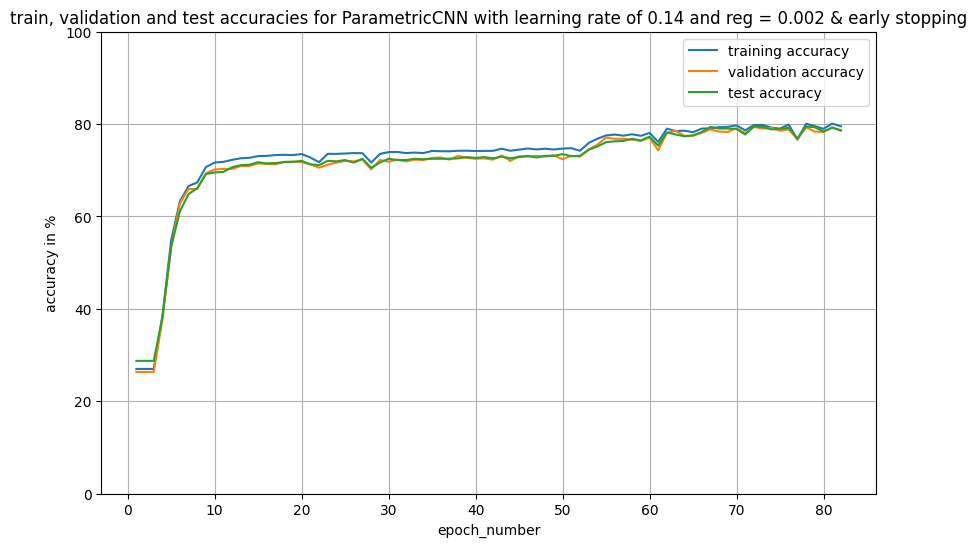

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epoch_log_d1, train_accuracy_log_d1, label='training accuracy')
ax.plot(epoch_log_d1, validation_accuracy_log_d1, label='validation accuracy')
ax.plot(epoch_log_d1, test_accuracy_log_d1, label='test accuracy')

ax.set_title('train, validation and test accuracies for ParametricCNN with learning rate of 0.14 and reg = 0.002 & early stopping')
ax.set_xlabel('epoch_number')
ax.set_ylabel('accuracy in %')
ax.set_ylim([0,100])

ax.legend()
ax.grid()

plt.show()